# <center>Generative AI course</center>
## <center>Seminar: Flow Matching </center>

<!-- <center>28.04.2026</center> -->

# Flow Matching

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Plan

In this seminar, we will understand how to train Flow Matching (FM) models on toy and real data setups.
     
- Flow Matching models on toy example:
   - FM using **independent** plans;
   - OT-FM using **minibatch** OT plans;
   - **Rectified** FM;
- Generation of colored MNIST images using FM models

In [ ]:
!pip install torchdyn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os

import torch
import torch.nn as nn
from tqdm import tqdm
from torchdyn.core import NeuralODE
from torchvision import datasets, transforms

if torch.cuda.is_available():
    DEVICE = "cuda:0"
else:
    DEVICE = "cpu"

print(f'Used hardware: {DEVICE}')

Used hardware: cuda:0


### Utils

In [ ]:
def visualize_2d_samples(data, title, c=None, xlabel=None, ylabel=None, label=None, s=4, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(data[:, 0], data[:, 1], s=s, c=c, label=label)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    if label is not None:
        ax.legend(fontsize=12)
    return ax


def plot_trajectories_fn(x, title, num_traj=25, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(x[-1, :, 0], x[-1, :, 1],
                    c='crimson',
                    marker='o',
                    s=30,
                    alpha=0.7,
                    label='Target')

    for i in range(min(x.shape[1], num_traj)):

        ax.plot(x[:, i, 0], x[:, i, 1],
                     color='black',
                     alpha=0.5,
                     linewidth=1.5, label='Trajs' if i == 0 else None)


    ax.scatter(x[0, :, 0], x[0, :, 1],
                    c='limegreen',
                    marker='X',
                    s=30,
                    alpha=0.7,
                    label='Source' if i == 0 else None)

    ax.set_title(title)
    ax.set_xlabel("x[0]")
    ax.set_ylabel("x[1]")
    ax.grid(True, alpha=0.3)  # Add subtle grid
    ax.legend()  # Show legend with unique entries


def plot_losses(x, losses, color="blue", alpha=0.5, plot_trajectories=False, num_traj=25):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

    if plot_trajectories:

        plot_trajectories_fn(x, "ODE Trajectories", num_traj=num_traj, ax=axes[0])

    else:

        axes[0].scatter(x[:, 0], x[:, 1], color='salmon')
        axes[0].set_title("Generated samples")
        axes[0].legend()

    axes[1].plot(losses, color='red', linewidth=2)
    axes[1].set_title("Loss Over Time")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def plot_multiple_trajectores(xs, titles, num_traj=25, num_rows=1):
    num_cols = int(np.ceil(len(xs) / num_rows))
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 6 * num_rows))

    for ax, title, x in zip(axes.flat, titles, xs):
        plot_trajectories_fn(x, title, num_traj=num_traj, ax=ax)
    plt.tight_layout()


In [ ]:
def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

seed_everything(42)

## Generative problem setup

In [ ]:
class Sampler:
    def __init__(
        self, device=DEVICE,
    ):
        self.device = device

    def sample(self, batch_size=512):
        pass


class StandardNormalSampler(Sampler):
    def __init__(
        self, dim=2, device=DEVICE,
    ):
        super(StandardNormalSampler, self).__init__(device)
        self.dim = dim
        self.mean = np.zeros(self.dim, dtype=np.float32)
        self.cov = np.eye(self.dim, dtype=np.float32)
        self.var = self.dim

    def sample(self, batch_size=512):
        return torch.randn(
            batch_size, self.dim,
            device=self.device
        )

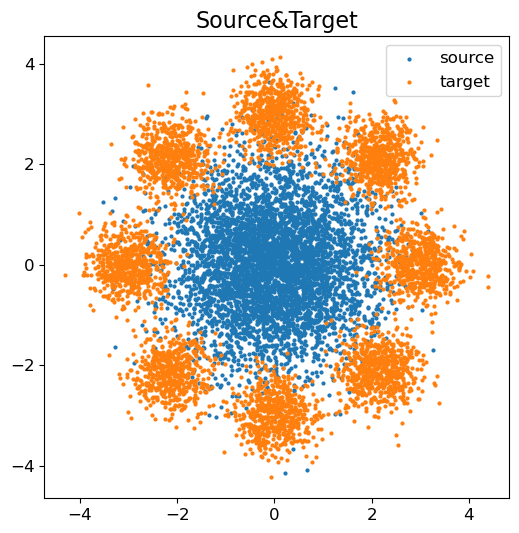

In [ ]:
class Mix8GaussiansSampler(Sampler):

    def __init__(
        self, with_central=False, std=1, r=12, dim=2, device=DEVICE,
    ):
        super().__init__(
            device=device
        )
        assert dim == 2
        self.dim = 2
        self.std, self.r = std, r

        self.with_central = with_central
        centers = [
            (1, 0), (-1, 0), (0, 1), (0, -1),
            (1. / np.sqrt(2), 1. / np.sqrt(2)),
            (1. / np.sqrt(2), -1. / np.sqrt(2)),
            (-1. / np.sqrt(2), 1. / np.sqrt(2)),
            (-1. / np.sqrt(2), -1. / np.sqrt(2))
        ]
        if self.with_central:
            centers.append((0, 0))
        self.centers = torch.tensor(
            centers, device=self.device
        )

    def sample(self, batch_size=512):
        batch = torch.randn(
            batch_size, self.dim,
            device=self.device
        )
        indices = random.choices(range(len(self.centers)), k=batch_size)
        batch *= self.std
        batch += self.r * self.centers[indices, :]
        return batch.clone().to(self.device)


mix8gau_sampler = Mix8GaussiansSampler(device=DEVICE, r=3, std=0.4)
standardnormal_sampler = StandardNormalSampler(device=DEVICE)

source_sampler = standardnormal_sampler
target_sampler = mix8gau_sampler

x_test_sample = source_sampler.sample(1024)

ax = visualize_2d_samples(source_sampler.sample(5024).cpu().numpy(), 'Source&Target', label='source')
visualize_2d_samples(target_sampler.sample(5024).cpu().numpy(), 'Source&Target', ax=ax, label='target')
plt.show()

## 1. Flow Matching (FM) on Toy Setup

<!-- In this task you have to train a [CFM](https://arxiv.org/pdf/2302.00482). Both will be trained using the Moons dataset from ```scikit-learn```. -->
Flow matching model is used for the task of translating samples from the **arbitrary** source distribution $p_0$ to the **arbitrary** target distribution $p_1$.


<center>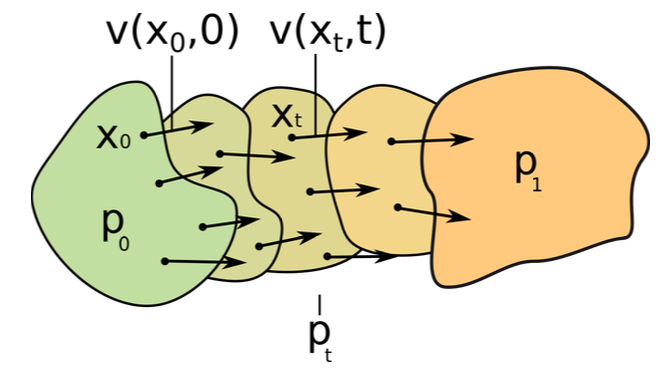</center>

**Main ideas of FM construction**.

We consider a vector field $v:\mathbb{R}^D\times [0,1]\mapsto \mathbb{R}^D$. For each point $x_0$, this vector field defines a trajectory $x_t$, such that
$$
\begin{cases}
d x_t = v(x_t,t) dt\\
x_t|_{t=0} = x_0
\end{cases}
$$
In other words $x_t(x_0) = x_0 + \int_0^{t} v(x_{\tau}, \tau)d\tau.$ If we know a vector field, we can simply construct the trajectories using neural ODE solvers, e.g., Euler method.

>*But how can we recover such a vector field which transports $p_0$ to $p_1$? That is, we need to ensure that for any $x_0\sim p_0$, $x_1(x_0) \sim p_1$.*

Consider a simple interpolation $x_t = x_0 \cdot (1-t) + x_1 \cdot t$ for any $x_0\sim p_0$, $x_1\sim p_1$. *How to find a corresponding vector field?* **One of such fields can be found as a solution of flow matching (FM) objective:**

$$
\min\limits_{v} \mathbb{E}_{x_0 \sim p_0\\x_1 \sim p_1} \; \{\mathbb{E}_{t\sim[0,1]} \;
\|v(x_t,t)-(x_1-x_0)\|^2\}
$$

See [[1]](#https://arxiv.org/pdf/2209.03003) for theoretical justification.

**Practical implementation.**

Empirical objective:

$$
\min\limits_{{\color{blue}v_{{\color{blue}\theta}}}} \mathbb{E}_{x_0 \sim p_0\\x_1 \sim p_1} \; \{\mathbb{E}_{t\sim[0,1]} \;
\|{\color{blue}v_{{\color{blue}\theta}}}(x_t,t)-(x_1-x_0)\|^2\}.
$$

Vector field is parametrized as a neural network ${\color{blue}v_{{\color{blue}\theta}}}(x_t,t)$ with inputs - data point and time (or time embedding). During training, we sample points $x_0\sim p_0$ and $x_1\sim p_1$, time $t$ randomly sampled from Uniform[0,1].

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, dim),
        )
        self.activation = nn.Tanh()

    def forward(self, x):
        return self.activation(x + self.block(x))

# taken from https://github.com/atong01/conditional-flow-matching/blob/main/torchcfm/utils.py
class torch_wrapper(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x, *args, **kwargs):
        return self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))

class CFMModel(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, num_blocks: int = 3, device='cuda:0'):
        super().__init__()
        self.input_layer = nn.Linear(input_dim + 1, hidden_dim)
        self.res_blocks = nn.Sequential(*[ResidualBlock(hidden_dim) for _ in range(num_blocks)])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        self.device = device

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        h = self.input_layer(x)
        h = self.res_blocks(h)
        return self.output_layer(h)

    def compute_xt(self, x, y, t):
        t = t[:, None]
        mu_t = y * t + (1 - t) * x
        return mu_t

    def compute_ut(self, x, y):

        return y - x

    @torch.no_grad()
    def sample(self, z, plot_trajectories=False):
        #x_test = torch.randn((n_samples, 2)).to(self.device)
        node = NeuralODE(torch_wrapper(self), solver="dopri5", atol=1e-4, rtol=1e-4)
        traj = node.trajectory(z, t_span=torch.linspace(0, 1, 100),)
        if plot_trajectories:
            samples, trajectories = traj[-1].cpu().detach(), traj.cpu().detach()
            return samples, trajectories
        else:
            samples = traj[-1].cpu().detach()
            return samples


### Flow Matching with independent plan

During training, we use pairs of points $(x,y)$ which are independently sampled from $p_0$ and $p_1$.


Independent plan `sample_fn`

In [ ]:
def get_idp_sample_fn(sampler_x, sampler_y, device=DEVICE):

    def ret_fn(batch_size):

        x_samples = sampler_x.sample(batch_size).to(device)
        y_samples = sampler_y.sample(batch_size).to(device)

        return x_samples, y_samples

    return ret_fn

sampling_fn = get_idp_sample_fn(source_sampler, target_sampler, device=DEVICE)

Flow matching loss implementation

In [ ]:
def train_fm(fm, sampling_fn, lr, n_epochs, batch_size, device, t0=0, t1=1):
    optimizer = torch.optim.Adam(fm.parameters(), lr=lr)
    losses = []
    fm.train()
    for i in tqdm(range(n_epochs)):

        optimizer.zero_grad()
        x, y = sampling_fn(batch_size)

        t = torch.rand(x.shape[0]).type_as(x)
        xt = fm.compute_xt(x, y, t)
        ut = fm.compute_ut(x, y)

        if t.dim() == 0:
            t = t.expand(x.size(0), 1)
        elif t.dim() == 1:
            t = t.unsqueeze(1)
        t = t.to(x.dtype).to(x.device)

        xt = torch.cat([xt, t], dim=1)

        vt = fm(xt)
        loss = torch.mean((vt - ut) ** 2)

        losses.append(loss.item())

        loss.backward()
        optimizer.step()

        if i % 1000 == 0:
            print('Iter: {}, running avg loss: {:.4f}'.format(i, loss.item()))
    return losses

Training Flow Matching with independent plan

In [ ]:
batch_size  = 512
input_dim   = 2
n_freqs     = 128
hidden_dims = n_freqs
lr          = 1e-3
n_epochs    = 5000

fm_idp_model = CFMModel(input_dim, device=DEVICE).to(DEVICE)

In [ ]:
losses = train_fm(fm_idp_model, sampling_fn, lr, n_epochs, batch_size, DEVICE, t0=0, t1=1)


  0%|          | 0/5000 [00:00<?, ?it/s]

Iter: 0, running avg loss: 5.5932
Iter: 1000, running avg loss: 2.9255
Iter: 2000, running avg loss: 3.2196
Iter: 3000, running avg loss: 2.9092
Iter: 4000, running avg loss: 3.2637


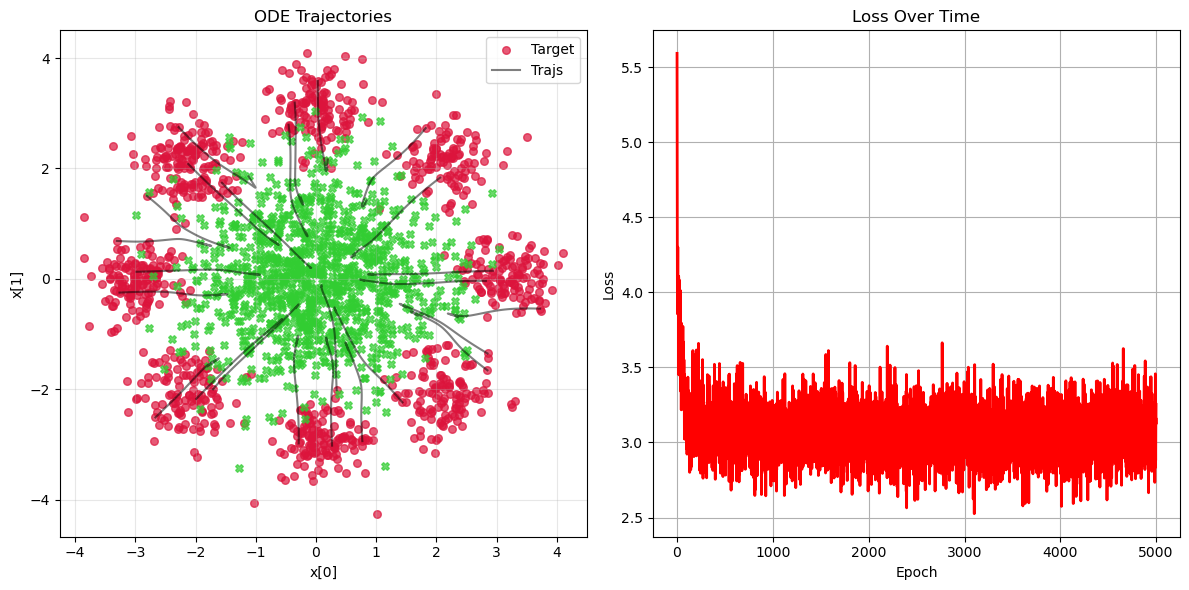

In [ ]:
_, trajectories = fm_idp_model.sample(x_test_sample , plot_trajectories=True)
plot_losses(trajectories, losses, plot_trajectories=True)


**Question:** *Trajectories are not stright enough! How to deal with that?!*

### Flow Matching with OT minibatch plan

Optimal Transport allow for finding the way of transforming one distribution $p_0$ into another $p_1$ while minimizing the *cost of transformation*. In fact, it defines optimal straight trajectories of transforming one distribution into another.
<!-- Optimal transport map $T^*$ is a solution of the problem
$$\mathbb{E}_{x\sim p_0} \;c(x, T(x)) \rightarrow min_T $$
where $c(x,y)$ is a given cost function. -->

Let us, first, sample $\{x^1,...,x^N\}\sim p_0$ and $\{y^1,...,y^N\}\sim p_1$ independently, then consider pairs $(x^i,y^j)\sim \pi(x,y)$ which are sampled from discrete OT plan estimated calculated on the initial minibatches. This variant of flow matching was proposed in [[2]](https://openreview.net/forum?id=CD9Snc73AW) and leads to a little bit straighter trajectories.

Auxiliary OT plan sampler.

In [ ]:
!pip install pot

In [ ]:
'''
The code is taken from https://github.com/SKholkin/LightSB-Matching
'''

import math
import numpy as np
import ot as pot


class OTPlanSampler:
    """OTPlanSampler implements sampling coordinates according to an OT plan (wrt squared Euclidean
    cost) with different implementations of the plan calculation."""

    def __init__(
        self,
        m_type='l2sq',
        **kwargs,
    ):
        r"""Initialize the OTPlanSampler class.

        Parameters
        ----------
        m_type: whether to use W2 (minibatch) or anti W2 (anti-minibatch)
        """
        # ot_fn should take (a, b, M) as arguments where a, b are marginals and
        # M is a cost matrix
        self.ot_fn = pot.emd
        self.kwargs = kwargs
        assert m_type in ['l2sq', 'anti_l2sq']
        self.m_type = m_type

    def get_map(self, x0, x1):
        """Compute the OT plan (wrt squared Euclidean cost) between a source and a target
        minibatch.

        Parameters
        ----------
        x0 : Tensor, shape (bs, *dim)
            represents the source minibatch
        x1 : Tensor, shape (bs, *dim)
            represents the source minibatch

        Returns
        -------
        p : numpy array, shape (bs, bs)
            represents the OT plan between minibatches
        """
        a, b = pot.unif(x0.shape[0]), pot.unif(x1.shape[0])
        if x0.dim() > 2:
            x0 = x0.reshape(x0.shape[0], -1)
        if x1.dim() > 2:
            x1 = x1.reshape(x1.shape[0], -1)
        x1 = x1.reshape(x1.shape[0], -1)
        M = torch.cdist(x0, x1) ** 2
        if self.m_type == 'anti_l2sq':
            M = - M
        p = self.ot_fn(a, b, M.detach().cpu().numpy())
        if not np.all(np.isfinite(p)):
            print("ERROR: p is not finite")
            print(p)
            print("Cost mean, max", M.mean(), M.max())
            print(x0, x1)
        return p

    def sample_map(self, pi, batch_size):
        r"""Draw source and target samples from pi  $(x,z) \sim \pi$

        Parameters
        ----------
        pi : numpy array, shape (bs, bs)
            represents the source minibatch
        batch_size : int
            represents the OT plan between minibatches

        Returns
        -------
        (i_s, i_j) : tuple of numpy arrays, shape (bs, bs)
            represents the indices of source and target data samples from $\pi$
        """
        p = pi.flatten()
        p = p / p.sum()
        choices = np.random.choice(pi.shape[0] * pi.shape[1], p=p, size=batch_size)
        return np.divmod(choices, pi.shape[1])

    def sample_plan(self, x0, x1):
        r"""Compute the OT plan $\pi$ (wrt squared Euclidean cost) between a source and a target
        minibatch and draw source and target samples from pi $(x,z) \sim \pi$

        Parameters
        ----------
        x0 : Tensor, shape (bs, *dim)
            represents the source minibatch
        x1 : Tensor, shape (bs, *dim)
            represents the source minibatch

        Returns
        -------
        x0[i] : Tensor, shape (bs, *dim)
            represents the source minibatch drawn from $\pi$
        x1[j] : Tensor, shape (bs, *dim)
            represents the source minibatch drawn from $\pi$
        """
        pi = self.get_map(x0, x1)
        i, j = self.sample_map(pi, x0.shape[0])
        return x0[i], x1[j]


Minibatch OT `sample_fn`

Additionally, we implement the possiblity to use *anti-* minibatch OT (not used in practice, inplemented in the seminar to show how the learned FM is affected by initial plan)

In [ ]:
def get_discrete_ot_plan_sample_fn(sampler_x, sampler_y, device='cuda', anti=False):

    m_type = 'l2sq' if not anti else 'anti_l2sq'
    ot_plan_sampler = OTPlanSampler(m_type=m_type)

    def ret_fn(batch_size):

        x_samples = sampler_x.sample(batch_size).to(device)
        y_samples = sampler_y.sample(batch_size).to(device)

        return ot_plan_sampler.sample_plan(x_samples, y_samples)

    return ret_fn

def get_discrete_smallbatch_ot_plan_sample_fn(sampler_x, sampler_y, mb_size=64, device='cuda', anti=False):
    sample_fn = get_discrete_ot_plan_sample_fn(sampler_x, sampler_y, device, anti=anti)

    def ret_fn(batch_size):
        spls_X = []
        spls_Y = []
        curr_sampled = 0
        while curr_sampled < batch_size:
            _X, _Y = sample_fn(mb_size)
            spls_X.append(_X); spls_Y.append(_Y)
            curr_sampled += mb_size
        X = torch.cat(spls_X); Y = torch.cat(spls_Y)
        return X[:batch_size], Y[:batch_size]

    return ret_fn

Flow matching with minibatch OT

In [ ]:
sampling_fn = get_discrete_smallbatch_ot_plan_sample_fn(
    source_sampler,
    target_sampler, mb_size=64, device=DEVICE, anti=False)

In [ ]:
batch_size  = 512
input_dim   = 2
n_freqs     = 128
hidden_dims = n_freqs
lr          = 1e-3
n_epochs    = 5000

fm_mb_model = CFMModel(input_dim, device=DEVICE).to(DEVICE)

In [ ]:
losses = train_fm(fm_mb_model, sampling_fn, lr, n_epochs, batch_size, DEVICE, t0=0, t1=1)

  0%|          | 0/5000 [00:00<?, ?it/s]

Iter: 0, running avg loss: 1.9885
Iter: 1000, running avg loss: 0.2329
Iter: 2000, running avg loss: 0.1940
Iter: 3000, running avg loss: 0.1792
Iter: 4000, running avg loss: 0.1810


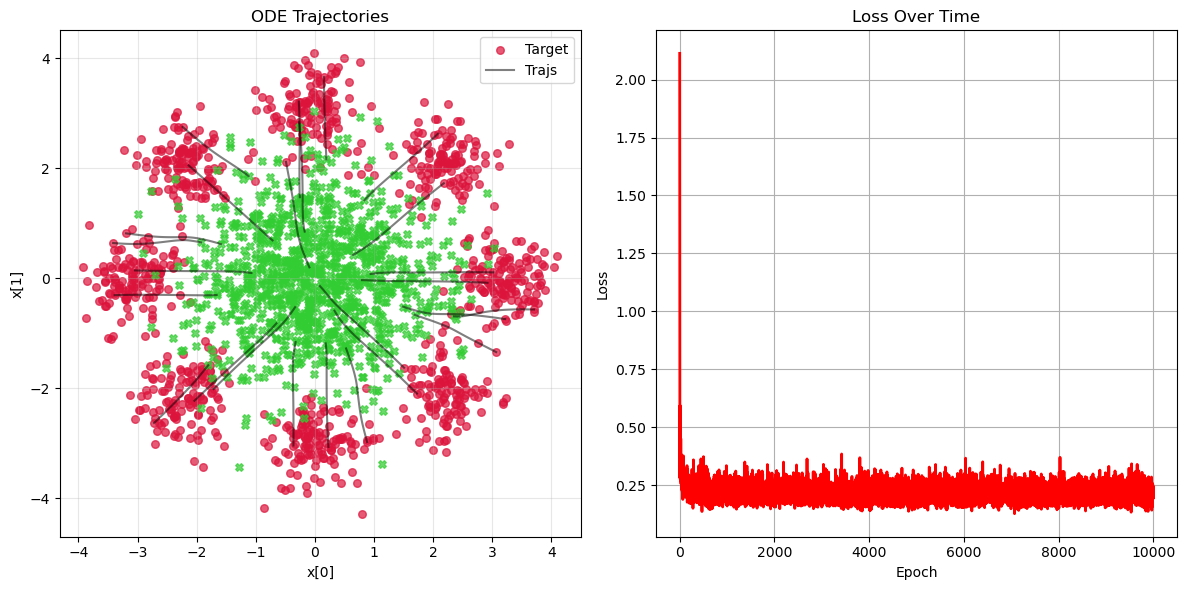

In [ ]:
final_samples, trajectories = fm_mb_model.sample(x_test_sample , plot_trajectories=True)
plot_losses(trajectories, losses, plot_trajectories=True)

#### Flow matching with **anti**-minibatch OT

In [ ]:
sampling_fn = get_discrete_smallbatch_ot_plan_sample_fn(
    source_sampler,
    target_sampler, mb_size=128, device=DEVICE, anti=True)

In [ ]:
batch_size  = 512
input_dim   = 2
n_freqs     = 128
hidden_dims = n_freqs
lr          = 1e-3
n_epochs    = 5000

fm_antimb_model = CFMModel(input_dim, device=DEVICE).to(DEVICE)

In [ ]:
losses = train_fm(fm_antimb_model, sampling_fn, lr, n_epochs, batch_size, DEVICE, t0=0, t1=1)

  0%|          | 0/5000 [00:00<?, ?it/s]

Iter: 0, running avg loss: 9.9940
Iter: 1000, running avg loss: 2.5365
Iter: 2000, running avg loss: 2.2862
Iter: 3000, running avg loss: 2.3611
Iter: 4000, running avg loss: 2.0753


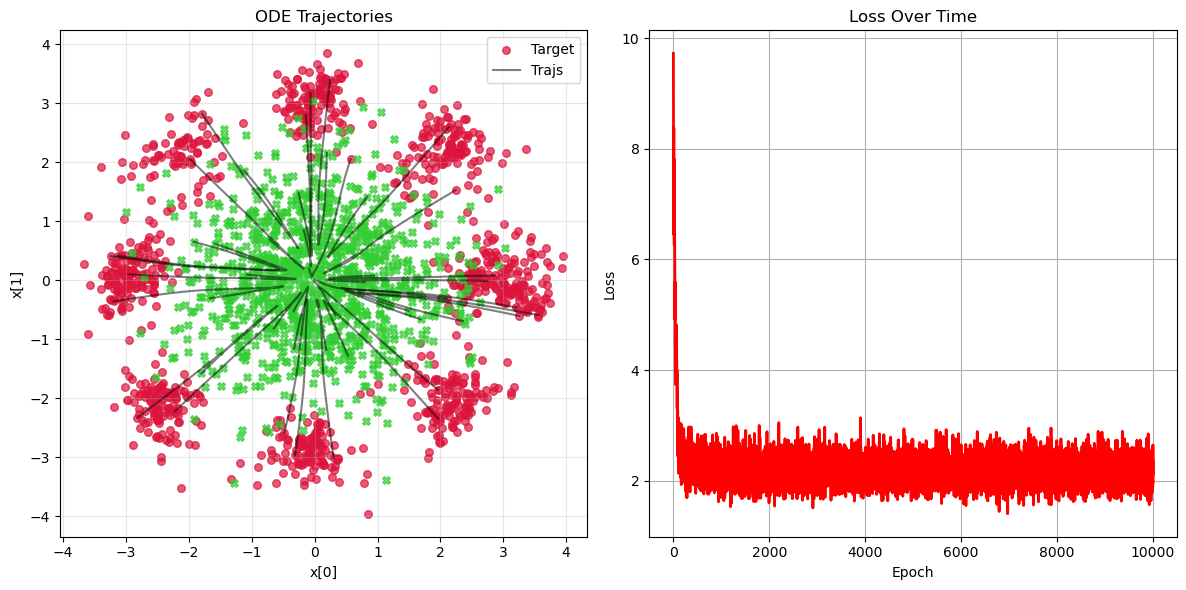

In [ ]:
final_samples, trajectories = fm_antimb_model.sample(x_test_sample , plot_trajectories=True)
plot_losses(trajectories, losses, plot_trajectories=True)

### Rectified Flow

The idea is to iteratively re-train FM model on the results obtained on previous step. We refer to [[3]](https://openreview.net/forum?id=XVjTT1nw5z) for further details. *Why does it work?*

**Statement.** If $c(x,y)$ has a form $h(x-y)$ (e.g., quadratic) than the results of trained FM model make the cost smaller: $\mathbb{E} c(x-y) \leq \mathbb{E} c(G_{fm}(x)-G_{fm}(y)).$

Informally, in a limit, we will get a process with **straight** trajectories which (up to some errors) correspond to solution of the OT problem. *What are the main problems here?*

Target matching error! The model doesn't learn true $p_1$ due to errors across FM iterations. Another problem - it is not simulation free now :(

In [ ]:
def get_reflow_sample_fn(sampler_x, fm_model, device=DEVICE):

    batch_size = 1024
    num_batches = 100

    print('sampler preparing...')
    X_buffer, Y_buffer = [], []
    for _ in tqdm(range(num_batches)):
        x_samples = sampler_x.sample(batch_size).to(DEVICE)
        y_samples = fm_model.sample(x_samples)
        X_buffer.append(x_samples.detach().cpu())
        Y_buffer.append(y_samples.detach().cpu())

    X_buffer = torch.cat(X_buffer, dim=0)
    Y_buffer = torch.cat(Y_buffer, dim=0)

    def ret_fn(batch_size):

        ids = torch.randint(0, len(X_buffer), (batch_size,))

        x_samples = X_buffer[ids].to(device)
        y_samples = Y_buffer[ids].to(device)

        return x_samples, y_samples

    return ret_fn

In [ ]:
sampling_fn = get_reflow_sample_fn(
    source_sampler,
    fm_antimb_model, device=DEVICE)

sampler preparing...


  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
batch_size  = 512
input_dim   = 2
n_freqs     = 128
hidden_dims = n_freqs
lr          = 1e-3
n_epochs    = 5000

fm_reflow_antimb_model = CFMModel(input_dim, device=DEVICE).to(DEVICE)

In [ ]:
losses = train_fm(fm_reflow_antimb_model, sampling_fn, lr, n_epochs, batch_size, DEVICE, t0=0, t1=1)

  0%|          | 0/5000 [00:00<?, ?it/s]

Iter: 0, running avg loss: 2.4329
Iter: 1000, running avg loss: 0.0011
Iter: 2000, running avg loss: 0.0005
Iter: 3000, running avg loss: 0.0005
Iter: 4000, running avg loss: 0.0005


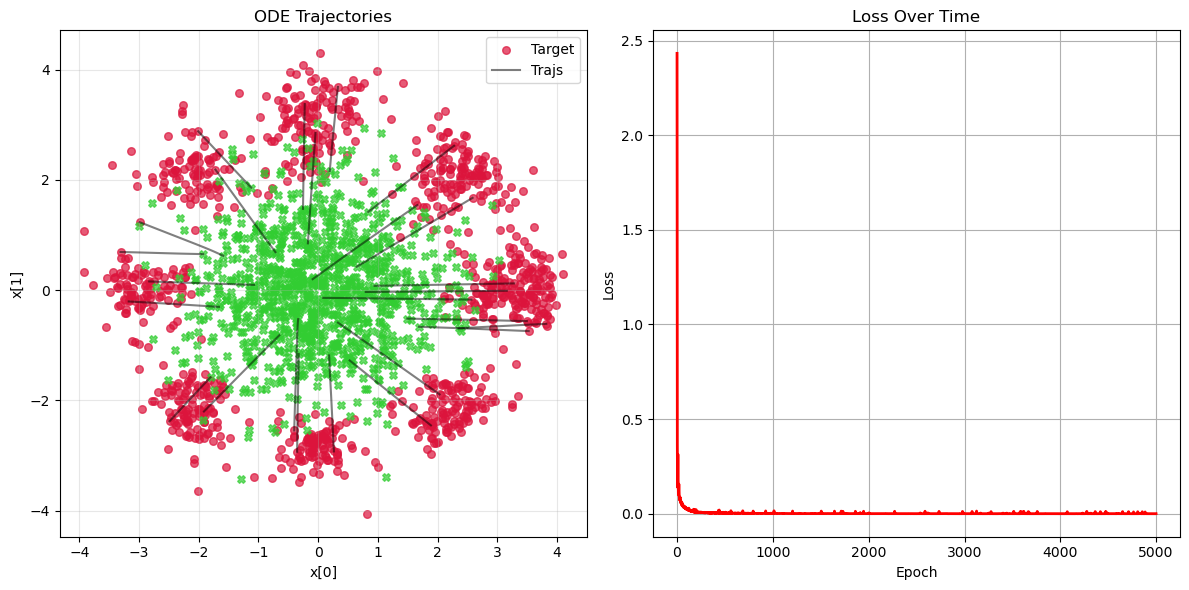

In [ ]:
final_samples, trajectories = fm_reflow_antimb_model.sample(x_test_sample , plot_trajectories=True)
plot_losses(trajectories, losses, plot_trajectories=True)

Final flow matchings

In [ ]:
_, trajs_idp = fm_idp_model.sample(x_test_sample , plot_trajectories=True)
_, trajs_mb = fm_mb_model.sample(x_test_sample , plot_trajectories=True)
_, trajs_antimb = fm_antimb_model.sample(x_test_sample , plot_trajectories=True)
_, trajs_reflow_antimb = fm_reflow_antimb_model.sample(x_test_sample , plot_trajectories=True)

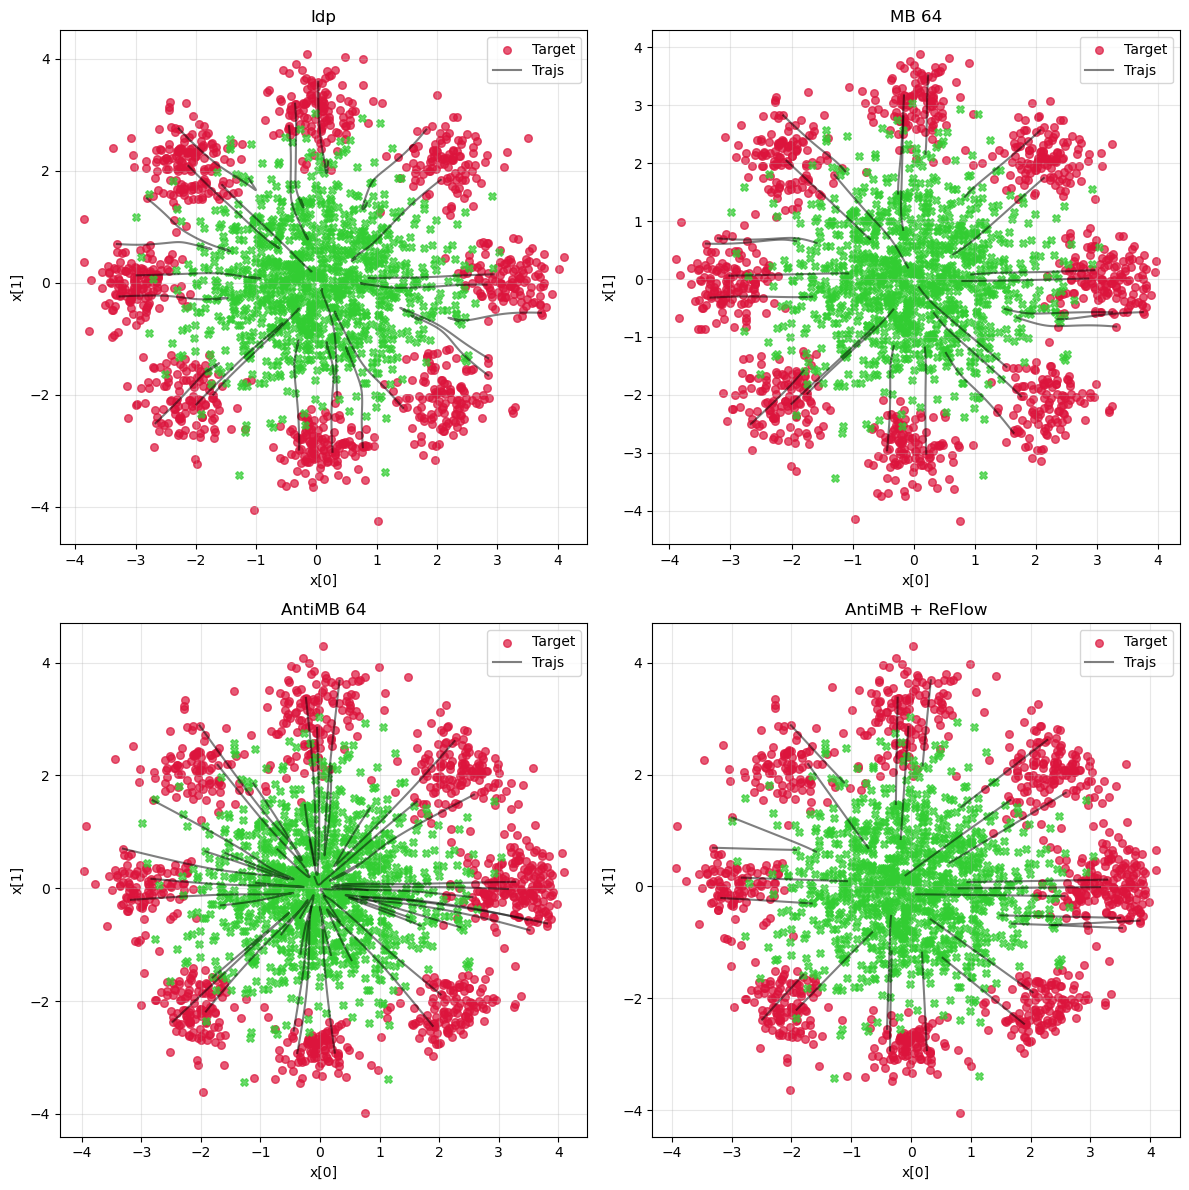

In [ ]:
plot_multiple_trajectores(
    xs=[trajs_idp, trajs_mb, trajs_antimb, trajs_reflow_antimb],
    titles=['Idp', 'MB 64', 'AntiMB 64', 'AntiMB + ReFlow'], num_traj=25,num_rows=2
)

## Part 2. Flow Matching for real-world task

In this section, we will apply flow matching for generation of colored MNIST digits.

### Data preprocessing

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST, USPS
from torch.utils.data import DataLoader, Dataset
import numpy as np
from torchdiffeq import odeint
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm
from sklearn.datasets import fetch_openml
from copy import deepcopy
import numpy as np
import torch
from torch.utils.data import TensorDataset
from typing import Optional, Union, Sequence, Dict, Tuple, List

import torchvision.datasets as TVdatasets
from torchvision import transforms as TVtransforms

In [ ]:
def random_color(im: torch.Tensor) -> torch.Tensor:
    hue = 360*np.random.rand()
    d = (im *(hue%60)/60)
    im_min, im_inc, im_dec = torch.zeros_like(im), d, im - d
    H = round(hue/60) % 6
    cmap = [[0, 3, 2], [2, 0, 3], [1, 0, 3], [1, 2, 0], [3, 1, 0], [0, 1, 2]]
    return torch.cat((im, im_min, im_dec, im_inc), dim=0)[cmap[H]]

In [ ]:
class CMNISTDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        digit: int = 0,
        train: bool = True,
        spat_dim: tuple[int, int] = (16, 16),
        download: bool = False,
        pix_range: tuple[float, float] = (-1.0, 1.0),
    ) -> None:
        self.digit = digit
        _m, _std = pix_range[0]/float(pix_range[0] - pix_range[1]), 1./float(pix_range[1] - pix_range[0])
        TRANSFORM = TVtransforms.Compose([
            TVtransforms.Resize(spat_dim),
            TVtransforms.ToTensor(),
            random_color,
            TVtransforms.Normalize([_m],[_std])
        ])
        self.mnist = TVdatasets.MNIST(root='./data', train=train, download=download, transform=TRANSFORM)
        mask = self.mnist.targets == digit
        if train:
            self.mnist.data = self.mnist.data[mask][:5900]
            self.mnist.targets = self.mnist.targets[mask][:5900]
        else:
            self.mnist.data = self.mnist.data[mask]
            self.mnist.targets = self.mnist.targets[mask]
    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx : int) -> torch.Tensor:

        return self.mnist[idx][0]#self.data[idx], self.targets[idx]

In [ ]:
TARGET_DIGIT = 3

In [ ]:
target_train = CMNISTDataset(TARGET_DIGIT, train=True, download=True)

row, col = target_train[0].shape[1], target_train[0].shape[2]
source_train  = torch.randn((5000,3,row,col))

print(f"Source train: {len(source_train)}")
print(f"Target train: {len(target_train)} images")

source_test = torch.randn((1000,3,row,col))
target_test = CMNISTDataset(TARGET_DIGIT, train=False, download=True)

print(f"Source test: {len(source_test)} images")
print(f"Target test: {len(target_test)} images")

Source train: 5000
Target train: 5900 images
Source test: 1000 images
Target test: 1010 images


In [ ]:
def plot_images(batch, title=None):
    fig, axes = plt.subplots(1, 10, figsize=(10, 1), dpi=100)
    for i in range(10):
        axes[i].imshow(batch[i].mul(0.5).add(0.5).clip(0, 1).permute(1, 2, 0))
        axes[i].set_xticks([])
        axes[i].set_yticks([])
    if title is not None:
        fig.suptitle(title, fontsize=16)
    fig.tight_layout(pad=0.1)
    plt.show()

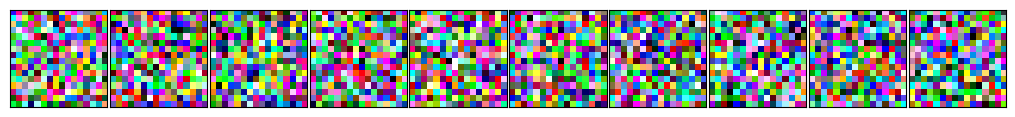

In [ ]:
SOURCE_IMAGES = next(iter(DataLoader(source_train, batch_size=10)))
plot_images(SOURCE_IMAGES)

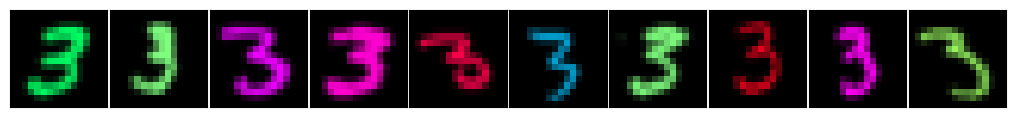

In [ ]:
TARGET_IMAGES = next(iter(DataLoader(target_train, batch_size=10)))
plot_images(TARGET_IMAGES)

### Implementation of the model

In [ ]:
from diffusers import UNet2DModel

class CFMModelMNIST_UNet(nn.Module):
    def __init__(self, image_size=16, device='cuda:0'):
        super().__init__()
        self.device = device
        # hint: one could use U-net neural network from diffusers
        self.net = UNet2DModel(
                                sample_size=32,           # image size (32x32)
                                in_channels=3,            # e.g., RGB images
                                out_channels=3,           # usually same as in_channels
                                layers_per_block=2,       # number of layers per resolution block

            block_out_channels=(64, 128, 256),  # feature channels at each block
                                down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"), # downsampling blocks
                                up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D"),         # upsampling blocks
                            )

    def forward(self, x_t, t):

        ret_val = self.net(x_t, t)

        return ret_val.sample

    def compute_xt(self, x, y, t):
        #Taken from https://github.com/atong01/conditional-flow-matching/blob/main/examples/2D_tutorials/Flow_matching_tutorial.ipynb
        t = t.reshape(-1, *([1] * (x.dim() - 1)))

        mu_t = t * y + (1 - t) * x
        return mu_t

    def compute_ut(self, x, y):
        return y - x

    @torch.no_grad()
    def sample(self, x, t_steps=50, rtol=1e-5, atol=1e-5):
        """
        New sampling method using ODE solver
        Args:
            x: Initial condition (typically noise) with shape [B, C, H, W]
            t_steps: Number of evaluation points (not directly used by adaptive solvers)
            solver: ODE solver type (e.g., 'dopri5', 'rk4', 'bosh3')
            rtol/atol: Tolerance parameters for adaptive solvers
        """
        # Define ODE function matching the model's dynamics
        def ode_fn(t, x):
            # Convert scalar t to batched tensor input
            batch_size = x.shape[0]
            t_tensor = t * torch.ones((batch_size,),
                                    device=x.device,
                                    dtype=x.dtype)
            return self.forward(x, t_tensor)

        # Time span [0, 1] for integration
        # print(self.device, x.device)
        t_span = torch.tensor([0., 1.], device=self.device)

        # Solve the ODE
        x_traj = odeint(
            ode_fn,
            x,                     # Initial state
            t_span,                # Integration interval
            method='dopri5',
            rtol=rtol,
            atol=atol
        )

        return x_traj[-1]  # Return final state at t=1

### Training loop

In [ ]:
def plot_images(samples, title=None):

    fig, axes = plt.subplots(1, 10, figsize=(10, 1), dpi=300)
    for i in range(10):
        axes[i].imshow(samples[i].mul(0.5).add(0.5).clip(0, 1).permute(1, 2, 0))
        axes[i].set_xticks([])
        axes[i].set_yticks([])
    if title is not None:
        fig.suptitle(title, fontsize=12)

    fig.tight_layout(pad=0.1)
    plt.show()

def get_samples(iter_dataloader, dataloader):
    try:
        images = next(iter_dataloader)
    except StopIteration:
        iter_dataloader = iter(dataloader)
        images = next(iter_dataloader)

    return images.to(DEVICE), iter_dataloader

def train_fm_mnist(fm_mnist, target_loader, lr, n_epochs, batch_size, device):

    optimizer = torch.optim.Adam(fm_mnist.parameters(), lr=lr)

    # Improved scheduler configuration
    total_steps = n_epochs * len(target_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-3,
        total_steps=total_steps,
        pct_start=0.25,
        anneal_strategy='cos'
    )

    # Gradient clipping
    grad_clip = 1.0

    losses = []

    target_iter_dataloader = iter(target_loader)

    x_test = torch.randn((batch_size, 3, row, col)).to(device)

    for i in tqdm(range(n_epochs)):
        fm_mnist.train()
        optimizer.zero_grad()

        x = torch.randn((batch_size, 3, row, col)).to(device)
        y, target_iter_dataloader = get_samples(target_iter_dataloader, target_loader)

        x    = x.to(device).to(torch.float32).requires_grad_(True)
        y    = y.to(device).to(torch.float32).requires_grad_(True)

        t = torch.rand(y.shape[0]).to(device)
        xt = fm_mnist.compute_xt(x, y, t)
        ut = fm_mnist.compute_ut(x, y)

        vt = fm_mnist(xt, t)

        loss = torch.mean((vt - ut) ** 2)
        losses.append(loss.item())

        # Backward pass with clipping
        loss.backward()

        # Optimizer step
        optimizer.step()
        #scheduler.step()

        if i % 500==0 or i==n_epochs-1:
            clear_output(wait=True)
            print('Iter: {}, running avg loss: {:.4f}'.format(i, loss.item()))
            fm_mnist.eval()
            with torch.no_grad():

                samples = fm_mnist.sample(x_test, 200)
                plot_images(samples[:10].cpu())

In [ ]:
img_size = (16, 16, 3)
hidden_dims = [256] * 8
lr = 1e-4
n_epochs = 10000
batch_size = 10

target_cmnist_loader = DataLoader(target_train, batch_size=batch_size, shuffle=True, drop_last=True)

fm_model_mnist = CFMModelMNIST_UNet().to(DEVICE)

# state_dict = torch.load('fm_cmnist_generation.ckpt')
# fm_model_mnist.load_state_dict(state_dict, strict=True)


Iter: 8500, running avg loss: 0.1012


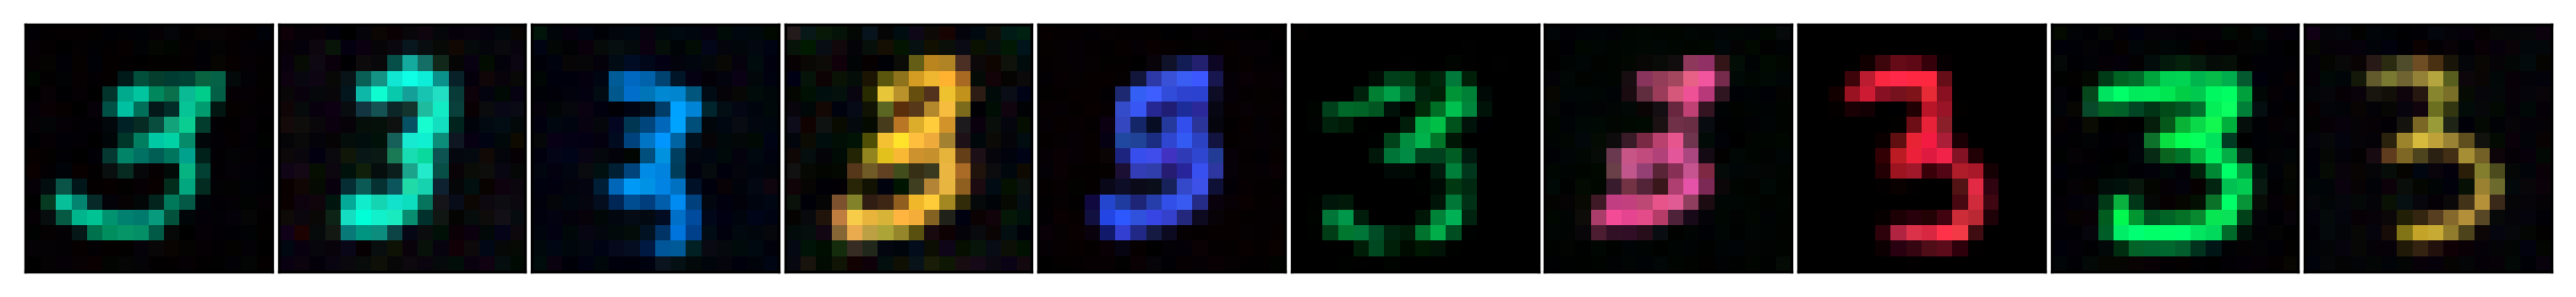

 90%|████████▉ | 8973/10000 [10:38<01:12, 14.21it/s]

In [ ]:
train_fm_mnist(fm_model_mnist, target_cmnist_loader, lr, n_epochs, batch_size, DEVICE)

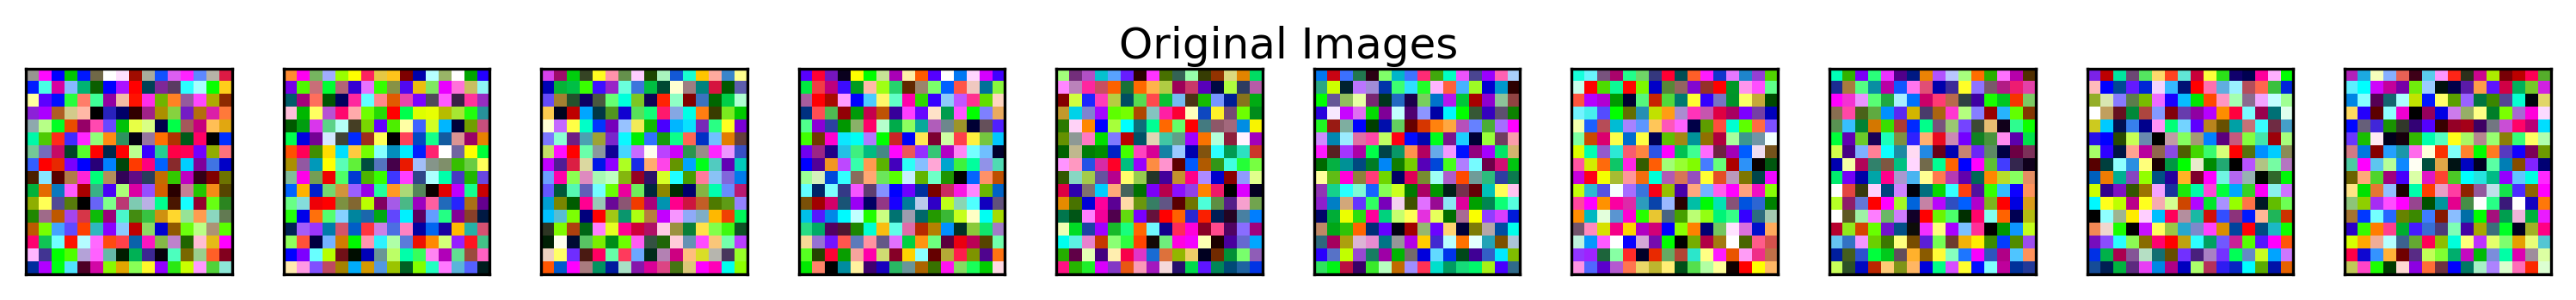

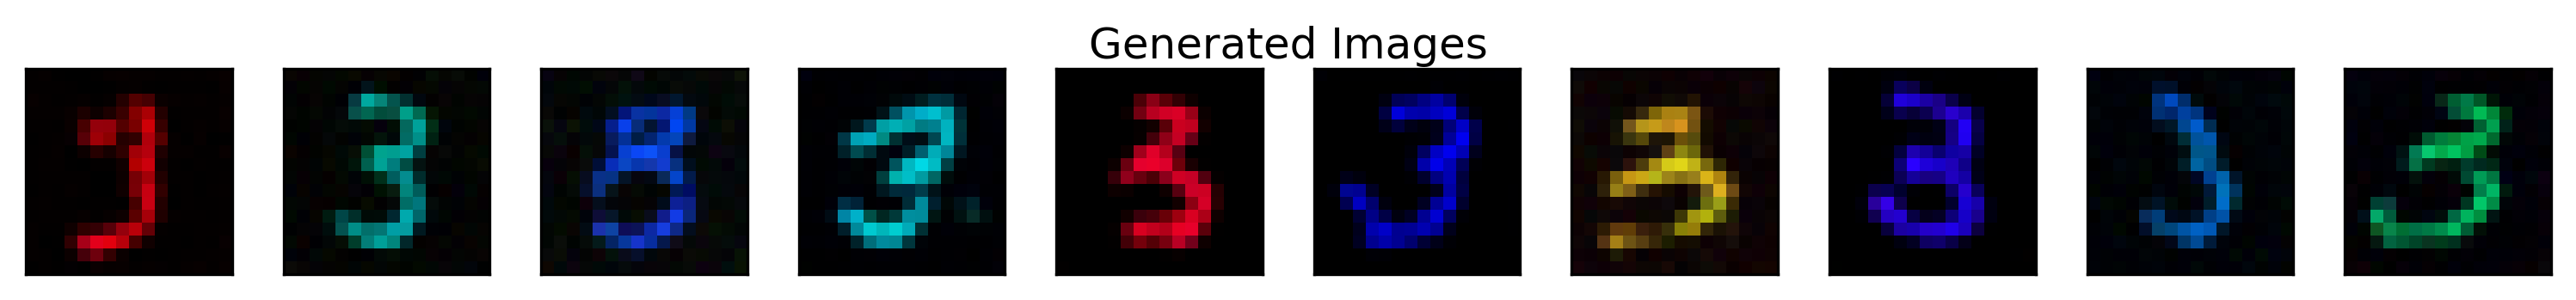

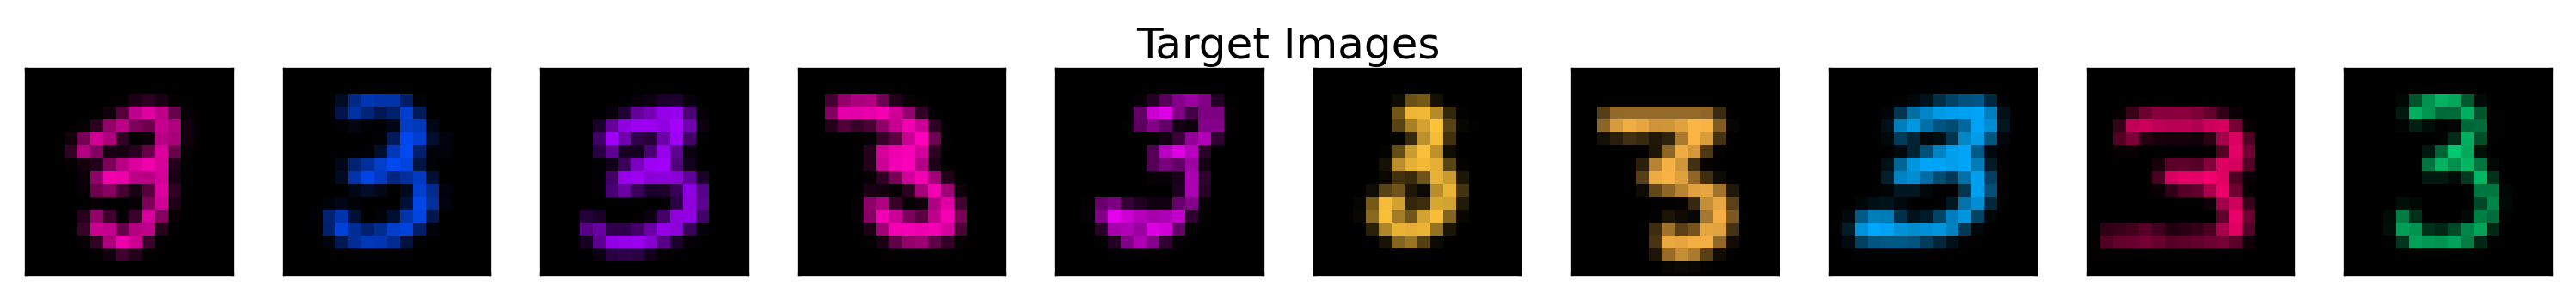

In [ ]:
x_test = torch.randn((batch_size, 3, row, col)).to(DEVICE) #next(iter(source_cmnist_loader))
y_test = next(iter(target_cmnist_loader)).to(DEVICE)

with torch.no_grad():
    samples = fm_model_mnist.sample(x_test, 200)

plot_images(x_test[:10].cpu(),  'Original Images')
plot_images(samples[:10].cpu(), 'Generated Images')
plot_images(y_test[:10].cpu(), 'Target Images')


In [ ]:
# torch.save(fm_model_mnist.state_dict(), 'fm_cmnist_generation.ckpt')